# Example: Cherenkov ring angular analysis 

This example shows the standardised, class-based way to do the *tank-side* part
of a pion / single-ring analysis:

1. load data and apply data-quality cuts with `DataLoader`,
2. (optionally) select a particle type from the beam monitors with `BeamSelection`,
3. use `RingGeometry` to turn each hit into an angle relative to the beam and a
   time residual (hit time minus time-of-flight from the beam entry point),
4. use `CherenkovRingSelection` to apply a prompt-time window and a Cherenkov-cone
   angular cut, and split each event's charge into the part **inside** the cone
   and the part **outside** it,
5. classify events into track-like (low charge outside the expectred cone) vs shower-like (high charge outside the expectred cone) topologies and plot.

The PMT positions come from Dean's `Geometry` package (design or survey
placements). The same code also works with the in-repo `DetectorGeometry` if you
prefer -- see the geometry cell.

### Imports

In [1]:
import time
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

# Note: if you edit analysis_tools (or change sys.path), do Kernel -> Restart,
# then re-run. A live kernel keeps the already-imported modules cached;
# importlib.reload(analysis_tools) does NOT reload its submodules.
import analysis_tools

from analysis_tools import (
    DataLoader,
    BeamSelection,
    RingGeometry,
    BeamGeometry,
    CherenkovRingSelection,
    RingResults,
    classify_charge_topology,
    plot_inside_vs_outside,
    load_geometry_package_positions,
    cherenkov_angle_deg,
    cherenkov_cone_halfangle,
)
# DetectorGeometry is also importable if you prefer the in-repo geometry:
# from analysis_tools import DetectorGeometry




#change later
# The Geometry package must be importable in THIS kernel. Point at the directory
# that CONTAINS the Geometry/ package folder, then verify before constructing.
# (Do Kernel -> Restart & Run All after changing paths; edits to imported modules
#  are not picked up by a live kernel.)
import sys
GEO_PKG_DIR = "/eos/user/s/staghayo/SWAN_projects/Geometry"   # dir containing Geometry/
GEO_FILE    = f"{GEO_PKG_DIR}/examples/wcte_bldg157.geo"

if GEO_PKG_DIR not in sys.path:
    sys.path.insert(0, GEO_PKG_DIR)
import Geometry                       # must succeed; check the printed path
print("Geometry at:", Geometry.__file__)

Geometry at: /eos/user/s/staghayo/SWAN_projects/Geometry/Geometry/__init__.py


### Open the file, use the data loader tools

Load the data in batches the same way as you did in "Example Using Data Loader" notebook.
You can apply the PID selection cuts to select a particle (in this example pions),
or run the analysis on samples with specific properties or on everything. 


In [2]:
run_number = 1610
FILE = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/{run_number}/WCTE_merged_production_R{run_number}.root"
loader = DataLoader(FILE)

# Apply the standard data-quality cuts. These are applied automatically to every
# batch returned by loader.iterate().
loader.apply_mPMT_data_quality_cuts()   # window + hit-level mPMT quality masks
loader.apply_vme_event_quality_cuts()    # VME digitisation / event quality

In [3]:
# Restrict to channels that read out stably during the run (slot*100 + pos).
good_slots, good_pos = loader.get_good_wcte_pmts()
good_channels = np.asarray(good_slots) * 100 + np.asarray(good_pos)
print(len(good_channels), "good WCTE PMT channels")

1562 good WCTE PMT channels


In the next cell you decide what momentum to use and it affects the size of the cherencov cone you're looking at

In [4]:
# Here you can use the nominal run momentum.
p_tank = abs(float(loader.get_vme_analysis_run_info()["run_momentum"]))  # MeV/c


# Or for a specific particle (pions here) uncomment the next line to use 
# the estimated particle momentum entering the tank found from the beam monitor detectors
#p_tank = abs(float(loader.get_vme_analysis_scalar_results()['momentum_after_beam_window_mean_pion']))  # MeV/c  

In [5]:
# grab one batch to look at
demo_batch = next(loader.iterate(step_size="50 MB"))


events = demo_batch

Optional cell next: apply cuts on beam montior detectors

In [6]:
# restrict to pions selected from the beam monitors.
vme = loader.get_vme_analysis_scalar_results()
tof_cut = vme['proton_tof_cut'] or 999
pion_sel = BeamSelection.pion(
    ["vme_act_eveto",  "<", vme['act_eveto_cut']],
    ["vme_act_tagger", "<", vme['act_tagger_cut']],
    ["vme_tof_corr",   "<", tof_cut],
)


events = demo_batch[pion_sel.mask(demo_batch)]

### Build the geometry / timing 

`RingGeometry` computes, for each hit, the angle `theta` between the beam
direction and the vector from the cone apex (the beam entry point) to the PMT,
and the time residual `delta_t = hit_time - distance / v_g`. For a fixed apex
these are precomputed once per channel.

PMT positions here come from Dean's **Geometry** package via
`from_geometry_package`. `place_info="est"` uses the survey
placements; pass `"design"` instead
for **design** positions.

The apex on default `origin = (0, 0, -1520+188)` is set approximately based on the beam pipe CAD file. 
The cone apex can also be set **per event** later (e.g.
the particle entry position from the T5 analysis) or for secondary rings -- see the final section.

In [7]:
# Bundle the beam configuration (apex, axis, particle, momentum) in one object,
# kept separate from the detector geometry. Momentum at the tank comes from the
# beam-side analysis or from a set value (defined earlier)

beam = BeamGeometry(
    origin=(0.0, 0.0, -1520.0 + 188.0),    # beam entry point, Geometry-package frame (mm)
    direction=(0.0, 0.0, 1.0),             # beam travels along +z
    momentum=p_tank,
    particle="pion",
    n=1.33,
)

ring = RingGeometry.from_geometry_package(
    GEO_FILE,    
    place_info="est",                      # survey/estimated; use "design" for design positions
    beam=beam,                             # apex + axis come from the BeamGeometry
)

# Alternative without the external package:
#   from analysis_tools import DetectorGeometry
#   ring = RingGeometry(geometry=DetectorGeometry(), beam=beam)


### Define the Cherenkov ring selection

`CherenkovRingSelection` is the hit-level analogue of `BeamSelection`: it holds
the cut values and turns hit arrays into per-event charge sums. The two cuts are:

- a **prompt-time window** `|delta_t - mu| < K` ns, where `mu` is found per event from 
  the peak of the time-residual distribution
  (for a single event you can also fit a gaussian to the time residual histogram
  and take the mean and standard deviation of gaussian), and
- a **Cherenkov-cone angular cut** `theta < angle_cut_deg`.

Derive the cone angle from the particle's Cherenkov
angle at that momentum, plus a margin (the momentum given to `BeamGeometry` object above). (You can still pass
a fixed value, e.g. `angle_cut_deg=44.0`, if you prefer.) `describe()` prints the
configuration.

In [10]:
# Cone half-angle from the beam's Cherenkov angle (+ margin) -- a fixed value can be given as input instead.
cone_deg = beam.cone_halfangle(margin_deg=5.0)
print(f"p = {beam.momentum:.0f} MeV/c -> Expected Cherenkov angle "
      f"{beam.cherenkov_angle_deg():.1f} deg, acceptance cone angle {cone_deg:.1f} deg")

sel = CherenkovRingSelection(
    ring_geometry=ring,
    angle_cut_deg=cone_deg,        # Cherenkov angle + margin
    time_window_K=3.0,             # prompt-time half-window (ns)
    fit_t_min=1670.0,              # bracket the prompt peak for the dt fit
    fit_t_max=1770.0,
    min_hits=10,                          # This is the minimum number of hits needed for the event to be processed, this is used to determin the status of the event later
    coarse_time_window=(1600.0, 1800.0),  # optional pre-cut on calibrated times based on . Note that these values are run dependent and should be re-optimized for other datasets.
    use_gaussian_fit=False,               # False for faster over a full run, histogram-peak mu vs fitting a gaussian and finding the mean
)
sel.describe()

p = 760 MeV/c -> Expected Cherenkov angle 40.1 deg, acceptance cone angle 45.1 deg
CherenkovRingSelection
  cone half-angle      : theta < 45.1416 deg
  time cut             : on
  prompt-time window   : |dt - mu| < 3 ns (peak found in [1670, 1770] ns, 100 bins)
  coarse time pre-cut  : 1600 < t < 1800 ns
  min valid hits       : 10


### Inspect a single event

Pass one event record and `do_plot=True` to see the time-residual fit, the
prompt window, and the `theta`-vs-`delta_t` scatter used for the cuts. This is
the quickest way to check that the geometry and time window are sensible before
running over the whole run.

process_event_charge returns a "status" value for each event, here are the definition of each:

"no_hits" — after the channel-quality keep (good-channel cut, and the coarse time window when the time cut is on) the event had no hits left. All output charges are 0.

"no_geom" — there were hits, but none had valid geometry (out-of-range slot/pos, e.g. NaN PMT positions). All output charges are 0.

"few_hits" — it had valid-geometry hits, but n_valid <= min_hits (default min_hits=10), so it's treated as too sparse to use. All charges zeroed.

"no_time" — it passed the hit-count requirement, but no hits fell in the prompt-time window (|Δt − μ| < K), so q_time = q_inside = q_outside = 0. Note q_total is kept here (it's the one failure stage that doesn't zero q_total). Only possible when apply_time_cut=True.

"ok" — passed everything; the charge values are real.

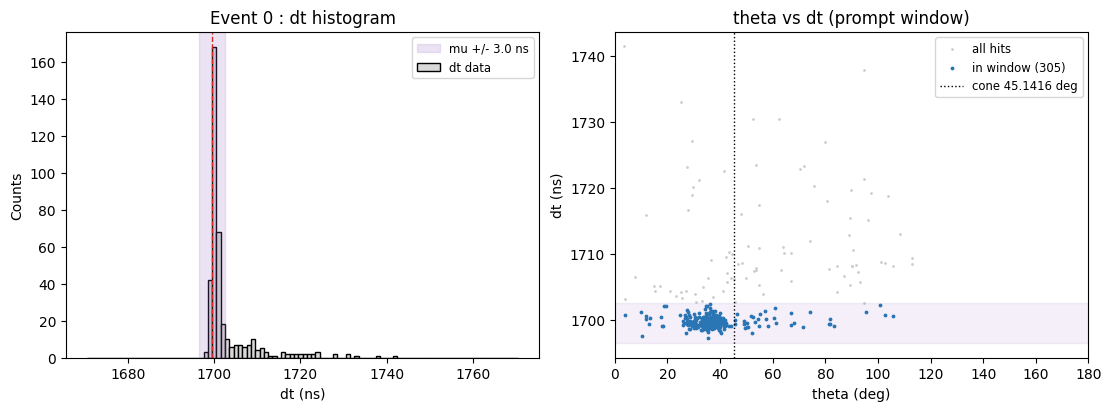

status   : ok
q_total  : 143925.0
q_time   : 130008.0
q_inside : 124060.0
q_outside: 5948.0


In [11]:
# grab one event from the example batch (demo_batch) to look at
res = sel.process_event_charge(event=events[0], event_id=0, do_plot=True)    # process_event_charge() applies the full ring selection to a single event. It computes q_total, q_time, q_inside and q_outside 
#using the same vectorised core as process_events(), making it useful for debugging and visualising individual events before processing an entire dataset.  

print("status   :", res["status"])      # 
print("q_total  :", res["q_total"])     # charge of all geometry-valid hits (after the coarse window, when the time cut is on)
print("q_time   :", res["q_time"])      # charge of the hits that also pass the prompt-time window
print("q_inside :", res["q_inside"])    # charge of the time-passing hits that are inside the cone
print("q_outside:", res["q_outside"])   # q_time − q_inside

### Do the analysis over the whole run in batches or on events in a single batch


You can iterate the loader and call `sel.process_events` on each batch in a for loop,
keeping a global event id with `start_index` so ids are unique across batches. Then concatenate
the per-batch `RingResults`.

`process_events` automatically takes a fast column-wise path when handed an
awkward batch, and with `use_gaussian_fit=False` it skips the per-event fit (only finds the maximum in time residual distribution for time cuts), so
the loop runs faster. If it is still slow, the cost is dominated by the number of events; pass
`max_events=...` while developing, or set `verbose=True` to see progress.

To select a single particle type first (e.g. pions), define a `BeamSelection`
and mask each batch with it before processing like we did earlier -- see the
"Example Using Data Loader" notebook for how to build the selection.

In [12]:
# start = time.time()
# batch_results = []
# n_seen = 0
# for batch in loader.iterate(step_size="100 MB"):
#     events = batch     #load one batch at the top, read a single one here example_batch
#     # events = batch[pion_sel.mask(batch)]   # uncomment to use the pion selection
#     r = sel.process_events(events, start_index=n_seen, verbose=True)
#     batch_results.append(r)
#     n_seen += len(events)

# results = RingResults.concatenate(batch_results)
# print(f"Processed {len(results)} events in {time.time() - start:.1f} s")
# print("rejected at each stage:", {k: len(v) for k, v in results.fail_ids.items()})

Here for the speed, we run the `process_events` on all events in a single batch `demo_batch`.


In [13]:
results = sel.process_events(events, verbose=True)

  1683 events, 1682 ok; rejected: {'no_hits': 1, 'no_geom': 0, 'few_hits': 0, 'no_time': 0}


### Charge inside vs outside the ring

Events that deposit most of their light inside the Cherenkov cone with little
outside are track-like; events with a lot of charge outside the cone are
shower-like (or hard scatters). `classify_charge_topology` splits the events on
the outside-cone charge and then bins each topology into low / mid / high bands
by the inside-cone charge percentiles. Adjust the thresholds for your run.

track_low   : 44
track_mid   : 143
track_high  : 7
shower_low  : 189
shower_mid  : 219
shower_high : 1053


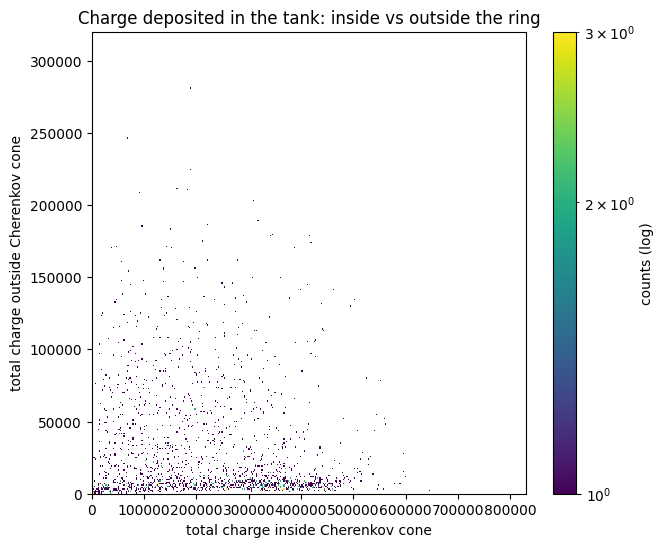

In [14]:
topology = classify_charge_topology(
    results.q_inside,
    results.q_outside,
    outside_track_max=3800.0,    # below this outside-charge -> track-like
    outside_shower_min=4000.0,   # above this outside-charge -> shower-like
)

for key in ("track_low", "track_mid", "track_high",
            "shower_low", "shower_mid", "shower_high"):
    print(f"{key:<12}: {int(topology[key].sum())}")

ax = plot_inside_vs_outside(
    results.q_inside, results.q_outside, topology=None,
    xlim=(0, 830000), ylim=(0, 320000),
    style="regions",   # shaded category regions over the density; "boundaries" or "scatter" also available
)
plt.show()

### Per-hit angles and the time residual

Set `return_hits=True` to get, per event, the jagged arrays of `theta` and
`delta_t` for the geometry-valid hits. These let you make the run-level
`theta`-vs-`delta_t` distribution (the prompt band you cut on) by simply
flattening across events with `ak.flatten`. Off by default because keeping every
hit is memory-heavy on a full run.

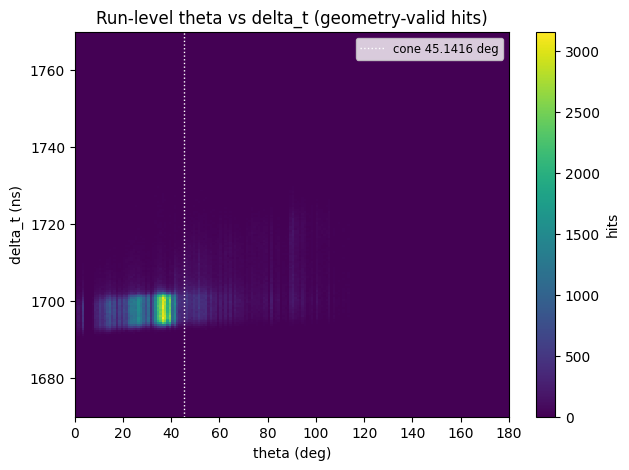

In [15]:
res_hits = sel.process_events(events, return_hits=True)   #need dt and angle before any cuts for single event or pmt as well

theta_deg = np.degrees(ak.to_numpy(ak.flatten(res_hits.theta)))
delta_t   = ak.to_numpy(ak.flatten(res_hits.delta_t))
fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(theta_deg, delta_t, bins=(180, 200),
              range=[(0, 180), (sel.fit_t_min, sel.fit_t_max)], cmap="viridis")
plt.colorbar(h[3], ax=ax, label="hits")
ax.axvline(sel.angle_cut_deg, color="w", ls=":", lw=1, label=f"cone {sel.angle_cut_deg:g} deg")
ax.set_xlabel("theta (deg)"); ax.set_ylabel("delta_t (ns)")
ax.set_title("Run-level theta vs delta_t (geometry-valid hits)")
ax.legend(loc="upper right", fontsize="small")
plt.show()

To debug, you can also call `sel.get_hit_quantities` on a single event to get `hit_info` which is a dictionary contianing mpmy slot number, pmt position number, charge, time, theta (rad), theta_deg, phi (rad), r (distance between the hit pmt and the origin in mm), tof (ns), delta_t (ns), and status for all hits in that event beofre applying the time and angle cuts.

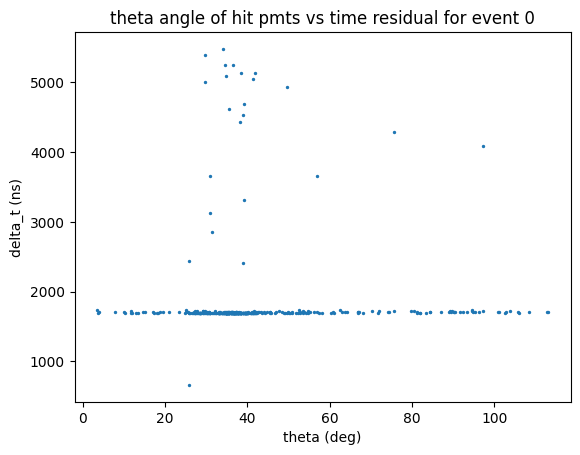

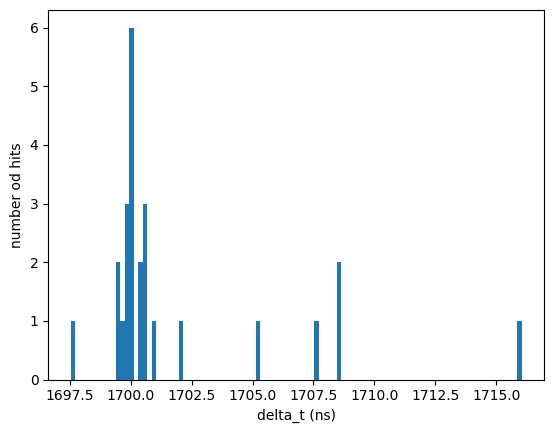

time residual (delta_t) for all the hits in pmt 18 in mpmt 71: [1699.39210833 5009.28261126 5393.48671282]


In [29]:
ev_ID = 0

hit_info = sel.get_hit_quantities(events[ev_ID])
plt.scatter(
    hit_info["theta_deg"],
    hit_info["delta_t"],
    s=2,
)
plt.xlabel("theta (deg)")
plt.ylabel("delta_t (ns)")
plt.title(f"theta angle of hit pmts vs time residual for event {ev_ID}")
plt.show() #this plot could tell you if your coarse_time_window selection was correct, as you should see a "horizontal line" for all the hits in the promt window


#Specific mPMTs:
mpmts = [21, 33, 105]
mask = np.isin(hit_info["slot"], mpmts)
plt.hist(
    hit_info["delta_t"][mask],
    bins=100
)
plt.xlabel("delta_t (ns)")
plt.ylabel("number od hits")
plt.show()


slot = 71
pos = 18
#Specific PMT inside one mPMT:
mask = (
    (hit_info["slot"] == slot)
    & (hit_info["pos"] == pos)
)
print(f"time residual (delta_t) for all the hits in pmt {pos} in mpmt {slot}:",hit_info["delta_t"][mask])


### Optional time cut

The prompt-time selection is optional. With `apply_time_cut=False` the coarse
window, time-of-flight subtraction and per-event prompt fit are all skipped, and
the charge is split inside/outside the cone using every hit passed in. Use this
once the timing is handled upstream (e.g. a T5 entry-time tool) and you feed in
already time-selected hits. Here is the effect on a single batch:

In [17]:
r_on  = sel.process_events(events, apply_time_cut=True)
r_off = sel.process_events(events, apply_time_cut=False)

print("time cut ON : q_time == q_total?", np.allclose(r_on.q_time, r_on.q_total))
print("time cut OFF: q_time == q_total?", np.allclose(r_off.q_time, r_off.q_total))
print("mean q_inside  on/off:", r_on.q_inside.mean(), "/", r_off.q_inside.mean())

time cut ON : q_time == q_total? False
time cut OFF: q_time == q_total? True
mean q_inside  on/off: 230133.08377896613 / 342701.07902554964


### Per-event cone apex (T5 entry position)

The cone apex defaults to the fixed `origin`. When the T5 analysis provides a
per-event entry position, pass it as `origins` (shape `(n_events, 3)`, in input
event order) so each particle gets its own apex; angles and time-of-flight are
then recomputed per hit. A single `(3,)` point applies to all events.

Until that tool is ready, the cell below just demonstrates the API by passing
the fixed origin for every event (which reproduces the default table path),
and a shifted apex to show it takes effect.

In [18]:
n_ev = len(events)

# Placeholder for the future T5 tool:
#   entry_positions = t5.get_entry_positions(demo_batch)   # (n_ev, 3) mm, event order
# For now, broadcast the fixed origin to every event:
entry_positions = np.tile(ring.origin, (n_ev, 1))

r_perorigin = sel.process_events(events, origins=entry_positions)
r_default   = sel.process_events(events)
print("fixed origin via origins= reproduces default:",
      np.allclose(r_perorigin.q_inside, r_default.q_inside))


#use T5.hit_pos_x[0] and y
# A shifted apex changes the angular split:
shifted = entry_positions.copy(); shifted[:, 2] += 200.0
r_shift = sel.process_events(events, origins=shifted)
print("shifted apex changes q_inside:",
      not np.allclose(r_shift.q_inside, r_default.q_inside))

fixed origin via origins= reproduces default: True
shifted apex changes q_inside: True


### Per-event cone angle (optional)

The selection above uses one Cherenkov cone angle computed from the
nominal run momentum. If the beam-side analysis gives a **per-event** momentum at the tank or for looking at secondary rings where you know the scattered particle's momentum,
you can pass a per-event angle so each event uses its own Cherenkov cone. Events
below threshold get NaN -> no charge counted inside the cone.

In [26]:
# If you have a per-event momentum array p_evt (MeV/c, in event order):
#   cone_evt = cherenkov_cone_halfangle(p_evt, particle="pion", margin_deg=5.0)
#   res = sel.process_events(demo_batch, angle_cut_deg=cone_evt)
#
# Demonstrate the API by broadcasting the nominal angle to every event
# (reproduces the default), then widening it:
n_ev = len(events)
res_default = sel.process_events(events)
res_evt = sel.process_events(events, angle_cut_deg=np.full(n_ev, cone_deg))
print("per-event angle == nominal:", np.allclose(res_default.q_inside, res_evt.q_inside))

per-event angle == nominal: True


### Standardised event-level outputs


#see how complicated it is, maybe move it back here instead of the 

`RingResults` exposes `ring_fraction` (= q_inside / q_total) and
`outside_fraction` (= q_outside / q_total) per event; Where q_total is the total charge 
without any cuts, so `ring_fraction` is not just `1- outside_fraction` as `q_inside + q_outside = q_time`

inside_cone_fraction    (first 5 events): [0.862 0.857 0.84  0.625 0.863]
outside_cone_fraction (first 5 events): [0.041 0.073 0.107 0.258 0.05 ]


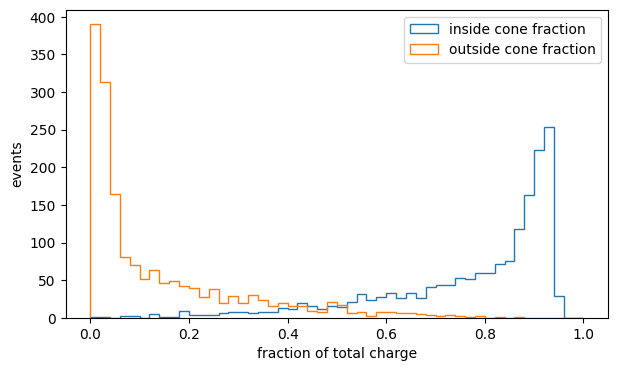

In [27]:
print("inside_cone_fraction    (first 5 events):", np.round(results.ring_fraction[:5], 3))
print("outside_cone_fraction (first 5 events):", np.round(results.outside_fraction[:5], 3))


#plot the inside the expected cone fraction and outside for all events in the batch
fig, ax = plt.subplots(figsize=(7, 4))
ok = results.q_total > 0    #events that have more than 10 valid-geometry hits and some passed the time cuts too
ax.hist(results.ring_fraction[ok], bins=50, range=(0, 1), histtype="step", label="inside cone fraction")
ax.hist(results.outside_fraction[ok], bins=50, range=(0, 1), histtype="step", label="outside cone fraction")
ax.set_xlabel("fraction of total charge"); ax.set_ylabel("events")
ax.legend(); plt.show()

### Custom cone apex and axis (secondary rings)

Both the apex (`origins`) and the axis (`beam_directions`) can be overridden,
per call, as a single vector or a per-event `(n_events, 3)` array. For the
primary beam ring the axis is `(0, 0, 1)`; for a secondary ring you would put
the apex at the interaction vertex and the axis along the secondary particle's
direction. Only `theta` (angle from the axis) enters the inside/outside cut.

In [28]:
# Example: same apex, but tilt the cone axis by 10 deg in x-z, for every event.
tilt = np.deg2rad(10.0)
axis = np.array([np.sin(tilt), 0.0, np.cos(tilt)])

res_default = sel.process_events(events)
res_tilted  = sel.process_events(events, beam_directions=axis)
print("tilting the cone axis changes q_inside:",
      not np.allclose(res_default.q_inside, res_tilted.q_inside))

# For a real secondary ring you would pass per-event arrays, e.g.
#   vertices    = ...   # (n_events, 3) interaction points (mm)
#   directions  = ...   # (n_events, 3) secondary particle directions
#   res2 = sel.process_events(demo_batch, origins=vertices, beam_directions=directions)

tilting the cone axis changes q_inside: True


### Save the event categories

Save the event ids per category so they can be cross-checked against the beam
monitor detectors (e.g. confirm the beam PID for each topology band).

In [ ]:
np.savez(
    f"ring_charge_splits_r{run_number}.npz",
    event_id=results.event_id,
    q_inside=results.q_inside,
    q_outside=results.q_outside,
    track_cuts=topology["track_cuts"],
    shower_cuts=topology["shower_cuts"],
    **{k: np.where(topology[k])[0] for k in
       ("track_low", "track_mid", "track_high",
        "shower_low", "shower_mid", "shower_high")},
)
print("saved")